In [2]:
!pip install gdsfactory_install
!gfi install

   ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.2 MB 660.6 kB/s eta 0:00:31
   ---------------------------------------- 0.1/20.2 MB 787.7 kB/s eta 0:00:26
   -- ------------------------------------- 1.5/20.2 MB 10.5 MB/s eta 0:00:02
   -------------- ------------------------- 7.2/20.2 MB 38.2 MB/s eta 0:00:01
   ------------------------- -------------- 12.8/20.2 MB 108.8 MB/s eta 0:00:01
   --------------------------- ------------ 13.9/20.2 MB 93.9 MB/s eta 0:00:01
   ------------------------------ --------- 15.6/20.2 MB 65.6 MB/s eta 0:00:01
   ---------------------------------------  20.2/20.2 MB 59.5 MB/s eta 0:00:01
   ---------------------------------------  20.2/20.2 MB 59.5 MB/s eta 0:00:01
   ---------------------------------------- 20.2/20.2 MB 40.9 MB/s eta 0:00:00


Resolved 101 packages in 6.47s
Prepared 101 packages in 42.29s
Installed 101 packages in 6.55s
 + aenum==3.1.16
 + annotated-types==0.7.0
 + asttokens==3.0.0
 + attrs==25.3.0
 + cachetools==6.1.0
 + certifi==2025.8.3
 + charset-normalizer==3.4.3
 + click==8.2.1
 + colorama==0.4.6
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.16
 + decorator==5.2.1
 + executing==2.2.0
 + fonttools==4.59.1
 + freetype-py==2.5.1
 + gdsfactory==9.12.2
 + gitdb==4.0.12
 + gitpython==3.1.45
 + graphviz==0.21
 + idna==3.10
 + imageio==2.37.0
 + ipyevents==2.0.2
 + ipykernel==6.30.1
 + ipython==9.4.0
 + ipython-pygments-lexers==1.1.1
 + ipytree==0.2.2
 + ipywidgets==8.1.7
 + jedi==0.19.2
 + jinja2==3.1.6
 + jupyter-client==8.6.3
 + jupyter-core==5.8.1
 + jupyterlab-widgets==3.0.15
 + kfactory==1.12.4
 + kiwisolver==1.4.9
 + klayout==0.30.3
 + lazy-loader==0.4
 + loguru==0.7.3
 + mapbox-earcut==1.0.3
 + markdown-it-py==4.0.0
 + markupsafe==3.0.2
 + matplotlib==3.10.5
 + matplotlib-inline=

In [15]:
!pip install -U jax jaxlib sax

   ---------------------------------------- 0.0/97.9 kB ? eta -:--:--
   ------------ --------------------------- 30.7/97.9 kB 640.0 kB/s eta 0:00:01
   ------------------------------------- -- 92.2/97.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 97.9/97.9 kB 1.1 MB/s eta 0:00:00
  Attempting uninstall: sax
    Found existing installation: sax 0.15.12
    Uninstalling sax-0.15.12:
      Successfully uninstalled sax-0.15.12


In [16]:
import gdsfactory as gf
import sax

AttributeError: partially initialized module 'jax' has no attribute 'version' (most likely due to a circular import)

# Direct Modulator

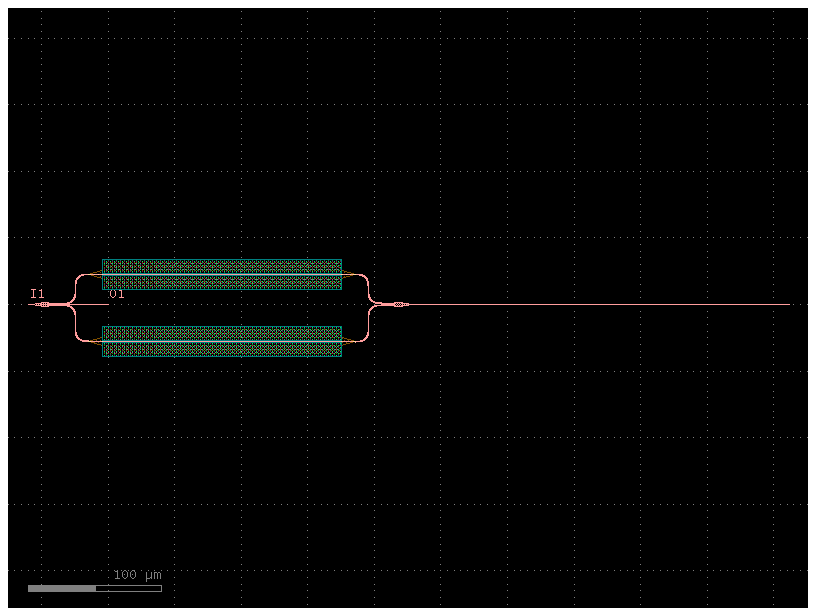

In [8]:
d = gf.Component()

mzm_bit = d << gf.components.mzm()
wg = d << gf.components.straight(length=50)

gf.routing.route_single(component=d, port1=mzm_bit.ports["o2"], port2=wg.ports["o1"], cross_section="strip")

d.add_port(name="I1", port=mzm_bit.ports["o1"])
d.add_port(name="O1", port=wg.ports["o2"])

d.draw_ports()
d.plot()

# 8-QAM Modulator

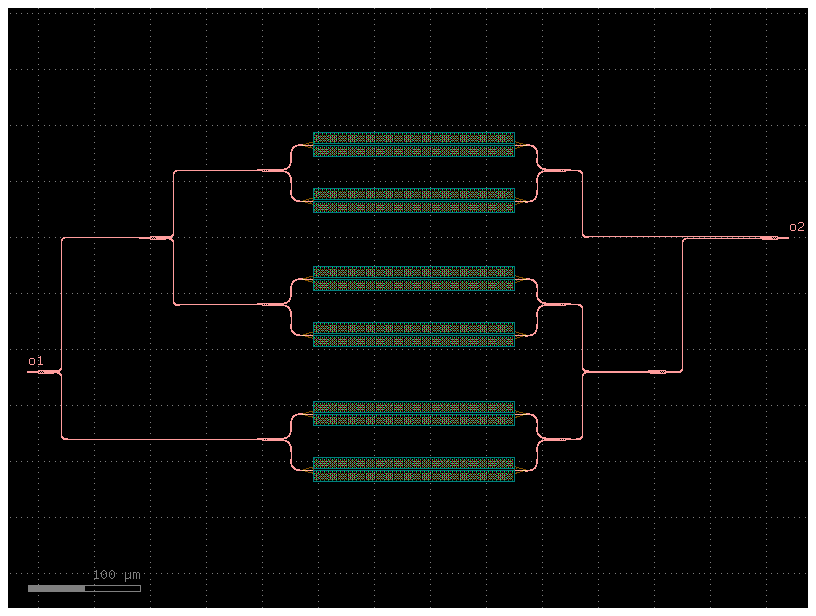

In [8]:
c = gf.Component()

mzm_bit1  = c << gf.components.mzis.mzm()
mzm_bit2  = c << gf.components.mzis.mzm()
mzm_bit3  = c << gf.components.mzis.mzm()
splitter1 = c << gf.components.mmi1x2()
splitter2 = c << gf.components.mmi1x2()
combiner1 = c << gf.components.mmi1x2()
combiner2 = c << gf.components.mmi1x2()

combiner1.rotate(180)
combiner2.rotate(180)

splitter1.move((-100,180))
splitter2.move((0,300))

mzm_bit1.move((100,360))
mzm_bit2.move((100,240))
mzm_bit3.move((100,120))

combiner1.move((460,180))
combiner2.move((560,300))

for p1, p2 in [
    (splitter1.ports["o2"], splitter2.ports["o1"]),
    (splitter1.ports["o3"], mzm_bit3.ports["o1"]),
    (splitter2.ports["o2"], mzm_bit1.ports["o1"]),
    (splitter2.ports["o3"], mzm_bit2.ports["o1"]),

    (mzm_bit1.ports["o2"], combiner2.ports["o3"]),
    (mzm_bit2.ports["o2"], combiner1.ports["o3"]),
    (mzm_bit3.ports["o2"], combiner1.ports["o2"]),
    (combiner1.ports["o1"], combiner2.ports["o2"])
]:
    gf.routing.route_single(c, p1, p2, cross_section="strip", radius=5)

c.add_port("o1", port=splitter1.ports["o1"])
c.add_port("o2", port=combiner2.ports["o1"])

c.draw_ports()
c.plot()

# Mach-Zehnder Modulator

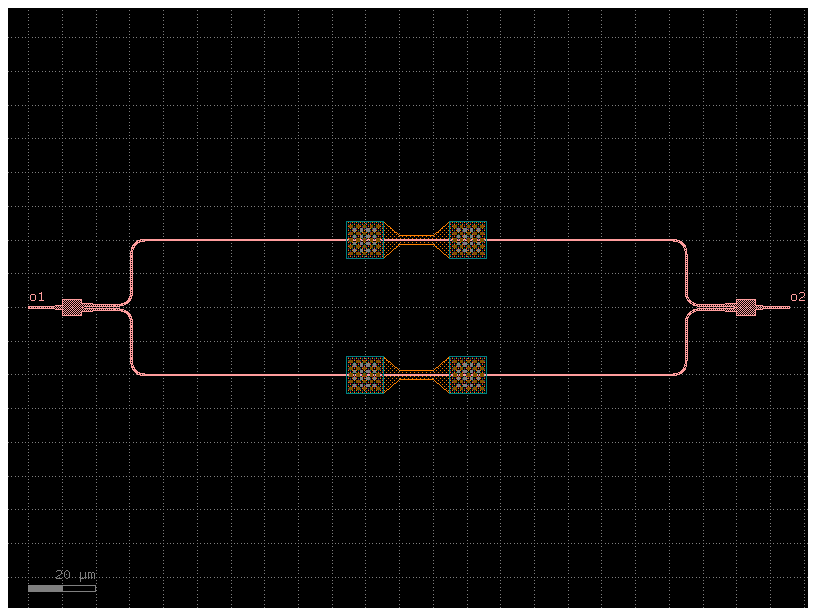

In [10]:
r = gf.Component()

mmi_splitter = r.add_ref(gf.components.mmi(inputs=1, outputs=2))
mmi_combiner = r.add_ref(gf.components.mmi(inputs=2, outputs=1))
ps1 = r.add_ref(gf.components.straight_heater_metal(length=10))
ps2 = r.add_ref(gf.components.straight_heater_metal(length=10))

mmi_splitter.move((0,0))
mmi_combiner.move((200, 0))
ps1.move((100, 20))
ps2.move((100, -20))

routes = []
for p1, p2 in [
    (mmi_splitter.ports["o2"], ps1.ports["o1"]),
    (mmi_splitter.ports["o3"], ps2.ports["o1"]),
    (mmi_combiner.ports["o2"], ps1.ports["o2"]),
    (mmi_combiner.ports["o1"], ps2.ports["o2"]),
]:
    gf.routing.route_single(component=r, port1=p1, port2=p2, cross_section="strip", radius=5)

r.add_port("o1", port=mmi_splitter.ports["o1"])
r.add_port("o2", port=mmi_combiner.ports["o3"])

r.draw_ports()
r.plot()